## Qsar Model - classical aproach: Problem Specific low data qsar modeling - Destinee - Zhu - Roy

**Overview:** This model employs RDKit molecular descriptors with machine learning algorithms optimized for low-data scenarios. RDKit descriptors are interpretable physical-chemical properties that characterize molecular structure.

**Key Features:**
- Over 200 interpretable RDKit descriptors (molecular weight, logP, topological indices, etc.)
- Low-data favorable algorithms with appropriate regularization
- Interpretable features facilitate chemical insight
- Suitable for small datasets common in early drug discovery

**Advantage:** Combines interpretability of descriptors with robust modeling approaches for limited experimental data.

In [ ]:
#!git clone https://github.com/swansonk14/admet_ai.git
#%cd admet_ai


In [ ]:
#!pip install -r requirements.txt
#!pip install -e .

In [ ]:
#from admet_ai import ADMETModel

#model = ADMETModel()
#preds = model.predict(smiles="O(c1ccc(cc1)CCOC)CC(O)CNC(C)C")

In [ ]:
#preds

In [ ]:
#!pip install pmapper

In [ ]:
#!pip install rdkit

In [ ]:
#from pmapper.pharmacophore import Pharmacophore as P
#from rdkit import Chem
#from rdkit.Chem import AllChem
#from pprint import pprint

## Data loading and Preprocessing



In [ ]:
# For Reporducibility
import numpy as np
np.random.seed(42)


### Set Random Seed for Reproducibility

**Purpose:** Fix random seed to ensure consistent results across multiple runs.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Data Loading

In [ ]:
import pandas as pd
from google.colab import files

# ==============================
# 1️⃣ Upload Excel File
# ==============================
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# ==============================
# 2️⃣ Read All Sheets
# ==============================
df_dict = pd.read_excel(file_name, sheet_name=None)

# Print sheet names to verify
print("Sheet names:")
for i, name in enumerate(df_dict.keys()):
    print(i, name)



Series_A_Triazole     = list(df_dict.values())[2].copy()
Series_B_Cysteine     = list(df_dict.values())[3].copy()
Series_C_Spiro        = list(df_dict.values())[4].copy()
Series_D_Pyrrolidine  = list(df_dict.values())[5].copy()
Series_E_Spiro        = list(df_dict.values())[6].copy()

# ==============================
# 4️⃣ Add Series_Name and Series_Code
# ==============================

Series_A_Triazole["Series_Name"] = "Series-A-Triazole"
Series_A_Triazole["Series_Code"] = "A"

Series_B_Cysteine["Series_Name"] = "Series-B-Cysteine"
Series_B_Cysteine["Series_Code"] = "B"

Series_C_Spiro["Series_Name"] = "Series-C-Spiro"
Series_C_Spiro["Series_Code"] = "C"

Series_D_Pyrrolidine["Series_Name"] = "Series-D-Pyrrolidine"
Series_D_Pyrrolidine["Series_Code"] = "D"

Series_E_Spiro["Series_Name"] = "Series-E-Spiro"
Series_E_Spiro["Series_Code"] = "E"

# ==============================
# 5️⃣ Preview First Sheet
# ==============================
Series_A_Triazole.head()

Saving TB Project QSAR.xlsx to TB Project QSAR (1).xlsx
Sheet names:
0 Convert
1 Input
2 Series A Triazole
3 Series B Cysteine
4 Series C Spiro
5 Series D Pyrrolidine
6 Series E Spiro (2)


,Identifier,Series,Canonical SMILES,Canonical SMILES.1,IC50 uM,PIC50,Series_Name,Series_Code
0,TB-VS0012,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(Cl)C=C3)N2C)=...,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(Cl)C=C3)N2C)=...,5.3,5.275724,Series-A-Triazole,A
1,TB-VS12-2,A,BrC1=CC(C2=NN=C(N2C)S)=CN=C1,BrC1=CC(C2=NN=C(N2C)S)=CN=C1,200,3.698970,Series-A-Triazole,A
2,TB-VS12-3,A,BrC1=CC(C2=NN=C(N2C)SCC3=CC=C(C=C3)Cl)=CN=C1,BrC1=CC(C2=NN=C(N2C)SCC3=CC=C(C=C3)Cl)=CN=C1,200,3.698970,Series-A-Triazole,A
3,TB-VS12-4,A,CCCCCCC#CC1=CC(C2=NN=C(N2C)S)=CN=C1,CCCCCCC#CC1=CC(C2=NN=C(N2C)S)=CN=C1,22.57,4.646468,Series-A-Triazole,A
4,TB-VS12-5,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=CC=C3)N2C)=CN=C1,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=CC=C3)N2C)=CN=C1,175,3.756962,Series-A-Triazole,A


In [ ]:
Series_E_Spiro

,Identifier,Series,Canonical SMILES,Canonical SMILES.1,IC50 uM,PIC50,Series_Name,Series_Code,Valid_SMILES,SMILES_Error,Clean_SMILES
0,ROY-0000308,C2,FC1=CC=C(C2=CC(N3CC4(CC3)CN(C(OC(C)(C)C)=O)C4)...,FC1=CC=C(C2=CC(N3CC4(CC3)CN(C(OC(C)(C)C)=O)C4)...,17.8,NaN,Series-E-Spiro,E,True,,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(-c4ccc(F)cc4)c3...
1,ROY-0000307,C2,BrC1=CC=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=N1,BrC1=CC=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=N1,63.6,NaN,Series-E-Spiro,E,True,,CC(C)(C)OC(=O)N1CC2(CCN(c3cccc(Br)n3)C2)C1
2,ROY-0000287,C2,CCCCCCOC1CN(C2=CN=CC(N3CCC4(CN(C(OC(C)(C)C)=O)...,CCCCCCOC1CN(C2=CN=CC(N3CCC4(CN(C(OC(C)(C)C)=O)...,6.07,NaN,Series-E-Spiro,E,True,,CCCCCCOC1CN(c2cncc(N3CCC4(CN(C(=O)OC(C)(C)C)C4...
3,ROY-0000286,C2,CC(OC(N1CC2(C1)CCN(C1=CC(N3CC(OCCCC4=CC=CC=C4)...,CC(OC(N1CC2(C1)CCN(C1=CC(N3CC(OCCCC4=CC=CC=C4)...,12.2,NaN,Series-E-Spiro,E,True,,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(N4CC(OCCCc5cccc...
4,ROY-0000277,C2,O=C(N1CC2(C1)CCN(C1=CC(C#CC3=CC=CC=C3)=CN=C1)C...,O=C(N1CC2(C1)CCN(C1=CC(C#CC3=CC=CC=C3)=CN=C1)C...,< 0.391,NaN,Series-E-Spiro,E,True,,O=C(c1cc([N+](=O)[O-])cc([N+](=O)[O-])c1)N1CC2...
5,ROY-0000275,C2,BrC1=CN=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=C1,BrC1=CN=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=C1,108,NaN,Series-E-Spiro,E,True,,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(Br)c3)C2)C1
6,ROY-0000268,C2,[H]N1CC2(C1)CCN(C1=CC(C#CC3=CC=CC=C3)=CN=C1)C2,[H]N1CC2(C1)CCN(C1=CC(C#CC3=CC=CC=C3)=CN=C1)C2,17,NaN,Series-E-Spiro,E,True,,C(#Cc1cncc(N2CCC3(CNC3)C2)c1)c1ccccc1


In [ ]:
!pip install rdkit

## Validity

In [ ]:
from rdkit import Chem
import pandas as pd

# List of your existing dataframes
series_dfs = [
    Series_A_Triazole,
    Series_B_Cysteine,
    Series_C_Spiro,
    Series_D_Pyrrolidine,
    Series_E_Spiro
]

# Function to validate SMILES
def validate_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return False, "Invalid_SMILES"
        else:
            return True, ""
    except:
        return False, "Parsing_Error"

# Apply validation to each dataframe
for df in series_dfs:
    if "Canonical SMILES.1" in df.columns:
        df[["Valid_SMILES", "SMILES_Error"]] = df["Canonical SMILES.1"].apply(
            lambda x: pd.Series(validate_smiles(x))
        )
    else:
        print(f"Column 'Canonical SMILES.1' not found in dataframe {df}")

[15:23:53] SMILES Parse Error: syntax error while parsing: CCCCCCC#CC1=CN=CC(C2=NN=C(SCC3=CC([N+]([O-])=O)=CC([N+]([O-])=O)=C3)N2C)=C1.[HCl]
[15:23:53] SMILES Parse Error: check for mistakes around position 80:
[15:23:53] ])=O)=C3)N2C)=C1.[HCl]
[15:23:53] ~~~~~~~~~~~~~~~~~~~~^
[15:23:53] SMILES Parse Error: Failed parsing SMILES 'CCCCCCC#CC1=CN=CC(C2=NN=C(SCC3=CC([N+]([O-])=O)=CC([N+]([O-])=O)=C3)N2C)=C1.[HCl]' for input: 'CCCCCCC#CC1=CN=CC(C2=NN=C(SCC3=CC([N+]([O-])=O)=CC([N+]([O-])=O)=C3)N2C)=C1.[HCl]'
[15:23:53] SMILES Parse Error: syntax error while parsing: CCCCCCC#CC1=CN=CC(C(N2C3CC3)=NN=C2SCC4=CC=C([N+]([O-])=O)O4)=C1.[HCl]
[15:23:53] SMILES Parse Error: check for mistakes around position 68:
[15:23:53] ]([O-])=O)O4)=C1.[HCl]
[15:23:53] ~~~~~~~~~~~~~~~~~~~~^
[15:23:53] SMILES Parse Error: Failed parsing SMILES 'CCCCCCC#CC1=CN=CC(C(N2C3CC3)=NN=C2SCC4=CC=C([N+]([O-])=O)O4)=C1.[HCl]' for input: 'CCCCCCC#CC1=CN=CC(C(N2C3CC3)=NN=C2SCC4=CC=C([N+]([O-])=O)O4)=C1.[HCl]'
[15:23:53] SMILE

In [ ]:
import re
import pandas as pd
from rdkit import Chem
from rdkit.Chem.SaltRemover import SaltRemover

# ---------------------------------
# DataFrames
# ---------------------------------
series_dfs = [
    Series_A_Triazole,
    Series_B_Cysteine,
    Series_C_Spiro,
    Series_D_Pyrrolidine,
    Series_E_Spiro
]

# ---------------------------------
# Salt remover
# ---------------------------------
remover = SaltRemover()

# ---------------------------------
# Preprocess SMILES
# ---------------------------------
def preprocess_smiles(smiles):

    if pd.isna(smiles):
        return smiles

    smiles = str(smiles)

    # Fix ammonium chloride
    smiles = re.sub(r"\[NH3\]Cl", "N", smiles)

    # Remove explicit HCl salts
    smiles = re.sub(r"\.\[HCl\]", "", smiles)
    smiles = re.sub(r"(\.\[HCl\])+", "", smiles)

    # Fix incorrect nitro groups
    smiles = smiles.replace("N(=O)(=O)", "[N+](=O)[O-]")

    return smiles


# ---------------------------------
# Clean + Validate SMILES
# ---------------------------------
def clean_validate_smiles(smiles):

    try:

        smiles = preprocess_smiles(smiles)

        mol = Chem.MolFromSmiles(smiles)

        if mol is None:
            return False, "Invalid_SMILES", None

        # Remove salts
        mol = remover.StripMol(mol, dontRemoveEverything=True)

        # Canonicalize
        clean_smiles = Chem.MolToSmiles(mol, canonical=True)

        return True, "", clean_smiles

    except Exception as e:

        return False, str(e), None


# ---------------------------------
# Apply cleaning to datasets
# ---------------------------------
for df in series_dfs:

    if "Canonical SMILES.1" in df.columns:

        df[["Valid_SMILES", "SMILES_Error", "Clean_SMILES"]] = df["Canonical SMILES.1"].apply(
            lambda x: pd.Series(clean_validate_smiles(x))
        )

    else:
        print("Column 'Canonical SMILES.1' not found.")


# ---------------------------------
# Summary
# ---------------------------------
for i, df in enumerate(series_dfs):

    total = len(df)
    valid = df["Valid_SMILES"].sum()
    invalid = total - valid

    print(f"\nSeries {i+1}: {valid}/{total} valid SMILES, {invalid} invalid")


# ---------------------------------
# Print invalid structures
# ---------------------------------
for i, df in enumerate(series_dfs):

    invalid_df = df[df["Valid_SMILES"] == False]

    if len(invalid_df) > 0:

        print("\n===============================")
        print(f"Series {i+1} Invalid Structures")
        print("===============================")

        for idx, row in invalid_df.iterrows():

            print("\nRow:", idx)
            print("Original:", row["Canonical SMILES.1"])
            print("Error:", row["SMILES_Error"])


Series 1: 122/122 valid SMILES, 0 invalid

Series 2: 39/39 valid SMILES, 0 invalid

Series 3: 6/6 valid SMILES, 0 invalid

Series 4: 8/8 valid SMILES, 0 invalid

Series 5: 7/7 valid SMILES, 0 invalid


In [ ]:
series_dfs

[    Identifier Series                                   Canonical SMILES  \
 0    TB-VS0012      A  CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(Cl)C=C3)N2C)=...   
 1    TB-VS12-2      A                       BrC1=CC(C2=NN=C(N2C)S)=CN=C1   
 2    TB-VS12-3      A       BrC1=CC(C2=NN=C(N2C)SCC3=CC=C(C=C3)Cl)=CN=C1   
 3    TB-VS12-4      A                CCCCCCC#CC1=CC(C2=NN=C(N2C)S)=CN=C1   
 4    TB-VS12-5      A    CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=CC=C3)N2C)=CN=C1   
 ..         ...    ...                                                ...   
 117         17      A  CCCCCCC#Cc1cncc(c1)c1nnc(n1CCO[C@H]1O[C@H]([C@...   
 118         18      A  CCCCCCC#Cc1cncc(c1)c1nnc(n1C)SC[C@H]1O[C@H]([C...   
 119         21      A  CCCCCCC#Cc1cncc(c1)c1nnc(n1C)SC[C@H]1O[C@H]([C...   
 120         22      A  CCCCCCC#Cc1cncc(c1)c1nnc(n1CCO)SC[C@H]1O[C@H](...   
 121         23      A  NCCCn1c(SC[C@H]2O[C@H]([C@@H]([C@@H]2O)O)Cn2cc...   
 
                                     Canonical SMILES.1 IC50 uM     PIC50 

In [ ]:
import pandas as pd

# List of your existing dataframes
series_dfs = [
    Series_A_Triazole,
    Series_B_Cysteine,
    Series_C_Spiro,
    Series_D_Pyrrolidine,
    Series_E_Spiro
]

# Collect all rows with invalid SMILES
invalid_smiles_list = []

for df in series_dfs:
    if "Valid_SMILES" in df.columns:
        invalid_rows = df[df["Valid_SMILES"] == False]
        invalid_smiles_list.append(invalid_rows)

# Combine all invalid SMILES into one dataframe
invalid_smiles_df = pd.concat(invalid_smiles_list, ignore_index=True)

# Preview
invalid_smiles_df.head()

,Identifier,Series,Canonical SMILES,Canonical SMILES.1,IC50 uM,PIC50,Series_Name,Series_Code,Valid_SMILES,SMILES_Error,Clean_SMILES


In [ ]:
import pandas as pd

# Combine all series dataframes into one
combined_df = pd.concat(series_dfs, ignore_index=True)

combined_df

,Identifier,Series,Canonical SMILES,Canonical SMILES.1,IC50 uM,PIC50,Series_Name,Series_Code,Valid_SMILES,SMILES_Error,Clean_SMILES
0,TB-VS0012,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(Cl)C=C3)N2C)=...,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(Cl)C=C3)N2C)=...,5.3,5.275724,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Cl)cc3)n2C)c1
1,TB-VS12-2,A,BrC1=CC(C2=NN=C(N2C)S)=CN=C1,BrC1=CC(C2=NN=C(N2C)S)=CN=C1,200,3.698970,Series-A-Triazole,A,True,,Cn1c(S)nnc1-c1cncc(Br)c1
2,TB-VS12-3,A,BrC1=CC(C2=NN=C(N2C)SCC3=CC=C(C=C3)Cl)=CN=C1,BrC1=CC(C2=NN=C(N2C)SCC3=CC=C(C=C3)Cl)=CN=C1,200,3.698970,Series-A-Triazole,A,True,,Cn1c(SCc2ccc(Cl)cc2)nnc1-c1cncc(Br)c1
3,TB-VS12-4,A,CCCCCCC#CC1=CC(C2=NN=C(N2C)S)=CN=C1,CCCCCCC#CC1=CC(C2=NN=C(N2C)S)=CN=C1,22.57,4.646468,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(S)n2C)c1
4,TB-VS12-5,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=CC=C3)N2C)=CN=C1,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=CC=C3)N2C)=CN=C1,175,3.756962,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccccc3)n2C)c1
...,...,...,...,...,...,...,...,...,...,...,...
177,ROY-0000287,C2,CCCCCCOC1CN(C2=CN=CC(N3CCC4(CN(C(OC(C)(C)C)=O)...,CCCCCCOC1CN(C2=CN=CC(N3CCC4(CN(C(OC(C)(C)C)=O)...,6.07,NaN,Series-E-Spiro,E,True,,CCCCCCOC1CN(c2cncc(N3CCC4(CN(C(=O)OC(C)(C)C)C4...
178,ROY-0000286,C2,CC(OC(N1CC2(C1)CCN(C1=CC(N3CC(OCCCC4=CC=CC=C4)...,CC(OC(N1CC2(C1)CCN(C1=CC(N3CC(OCCCC4=CC=CC=C4)...,12.2,NaN,Series-E-Spiro,E,True,,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(N4CC(OCCCc5cccc...
179,ROY-0000277,C2,O=C(N1CC2(C1)CCN(C1=CC(C#CC3=CC=CC=C3)=CN=C1)C...,O=C(N1CC2(C1)CCN(C1=CC(C#CC3=CC=CC=C3)=CN=C1)C...,< 0.391,NaN,Series-E-Spiro,E,True,,O=C(c1cc([N+](=O)[O-])cc([N+](=O)[O-])c1)N1CC2...
180,ROY-0000275,C2,BrC1=CN=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=C1,BrC1=CN=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=C1,108,NaN,Series-E-Spiro,E,True,,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(Br)c3)C2)C1


### Duplicate removal

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw

# Function to canonicalize SMILES
def canonicalize(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
    except:
        return None
    return None

# Make sure SMILES are canonical
combined_df['Canonical_SMILES'] = combined_df['Clean_SMILES'].apply(canonicalize)

# Drop rows with invalid SMILES
df = combined_df.dropna(subset=['Canonical_SMILES'])

# Create a column with RDKit molecule objects
df['Molecule'] = df['Canonical_SMILES'].apply(Chem.MolFromSmiles)

# Find all duplicates (all occurrences)
duplicates = df[df.duplicated(subset=['Canonical_SMILES'], keep=False)].sort_values('Canonical_SMILES')

# Optional: show duplicates with molecule structures
print("Duplicate molecules (all occurrences):")
print(duplicates[['Canonical_SMILES', 'Molecule']])

# Visualize a few molecules in Jupyter or IPython
# Draw.MolsToGridImage(duplicates['Molecule'].tolist()[:12], molsPerRow=4)

Duplicate molecules (all occurrences):
                                      Canonical_SMILES  \
76   CCCCCCC#Cc1cncc(-c2nnc(SC[C@H]3O[C@@H](n4ccc(=...   
80   CCCCCCC#Cc1cncc(-c2nnc(SC[C@H]3O[C@@H](n4ccc(=...   
40   CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(=O)[nH]c(=O)[nH]...   
104  CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(=O)[nH]c(=O)[nH]...   
86   CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(=O)[nH]c4ccccc34...   
103  CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(=O)[nH]c4ccccc34...   
114  CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(C(F)(F)F)cc(C(F)...   
94   CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(C(F)(F)F)cc(C(F)...   
32   CCCCCCC#Cc1cncc(-c2nnc(SCc3cc([N+](=O)[O-])cc(...   
74   CCCCCCC#Cc1cncc(-c2nnc(SCc3cc([N+](=O)[O-])cc(...   
99   CCCCCCC#Cc1cncc(-c2nnc(SCc3cc([N+](=O)[O-])cc(...   
116  CCCCCCC#Cc1cncc(-c2nnc(SCc3cc([N+](=O)[O-])cc(...   
96   CCCCCCC#Cc1cncc(-c2nnc(SCc3cc([N+](=O)[O-])cc(...   
109  CCCCCCC#Cc1cncc(-c2nnc(SCc3cc([N+](=O)[O-])cc(...   
92   CCCCCCC#Cc1cncc(-c2nnc(SCc3cc([N+](=O)[O-])cc(...   
0         CCCCCCC#Cc1cncc(-c2nnc(

In [ ]:
duplicates

,Identifier,Series,Canonical SMILES,Canonical SMILES.1,IC50 uM,PIC50,Series_Name,Series_Code,Valid_SMILES,SMILES_Error,Clean_SMILES,Canonical_SMILES,Molecule
76,TB-VS12-97,A,O=C1NC(C=CN1[C@@H]2O[C@H](CSC3=NN=C(C4=CC(C#CC...,O=C1NC(C=CN1[C@@H]2O[C@H](CSC3=NN=C(C4=CC(C#CC...,97.71,4.010061,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SC[C@H]3O[C@@H](n4ccc(=...,CCCCCCC#Cc1cncc(-c2nnc(SC[C@H]3O[C@@H](n4ccc(=...,<rdkit.Chem.rdchem.Mol object at 0x7b36456bcf20>
80,TB-VS12-97,A,O=C1NC(C=CN1[C@@H]2O[C@H](CSC3=NN=C(C4=CC(C#CC...,O=C1NC(C=CN1[C@@H]2O[C@H](CSC3=NN=C(C4=CC(C#CC...,97.71,4.010061,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SC[C@H]3O[C@@H](n4ccc(=...,CCCCCCC#Cc1cncc(-c2nnc(SC[C@H]3O[C@@H](n4ccc(=...,<rdkit.Chem.rdchem.Mol object at 0x7b36456bd0e0>
40,TB-VS12-43,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC(NC(N3)=O)=O)N2C...,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC(NC(N3)=O)=O)N2C...,200,3.698970,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(=O)[nH]c(=O)[nH]...,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(=O)[nH]c(=O)[nH]...,<rdkit.Chem.rdchem.Mol object at 0x7b3645627ed0>
104,5h,A,CCCCCCC#Cc1cncc(c1)c1nnc(n1C)SCc1cc(=O)[nH]c(=...,CCCCCCC#Cc1cncc(c1)c1nnc(n1C)SCc1cc(=O)[nH]c(=...,200,3.698970,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(=O)[nH]c(=O)[nH]...,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(=O)[nH]c(=O)[nH]...,<rdkit.Chem.rdchem.Mol object at 0x7b36456bdb60>
86,TB-VS12-103,A,O=C1NC2=C(C=CC=C2)C(CSC3=NN=C(C4=CC(C#CCCCCCC)...,O=C1NC2=C(C=CC=C2)C(CSC3=NN=C(C4=CC(C#CCCCCCC)...,200,3.698970,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(=O)[nH]c4ccccc34...,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(=O)[nH]c4ccccc34...,<rdkit.Chem.rdchem.Mol object at 0x7b36456bd380>
103,5g,A,CCCCCCC#Cc1cncc(c1)c1nnc(n1C)SCc1cc(=O)[nH]c2c...,CCCCCCC#Cc1cncc(c1)c1nnc(n1C)SCc1cc(=O)[nH]c2c...,200,3.698970,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(=O)[nH]c4ccccc34...,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(=O)[nH]c4ccccc34...,<rdkit.Chem.rdchem.Mol object at 0x7b36456bdaf0>
114,12e,A,NCCCn1c(nnc1c1cncc(c1)C#CCCCCCC)SCc1cc(cc(c1)C...,NCCCn1c(nnc1c1cncc(c1)C#CCCCCCC)SCc1cc(cc(c1)C...,3.12,5.505845,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(C(F)(F)F)cc(C(F)...,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(C(F)(F)F)cc(C(F)...,<rdkit.Chem.rdchem.Mol object at 0x7b36456bdfc0>
94,TB-VS12-113,A,NCCCN1C(SCC2=CC(C(F)(F)F)=CC(C(F)(F)F)=C2)=NN=...,NCCCN1C(SCC2=CC(C(F)(F)F)=CC(C(F)(F)F)=C2)=NN=...,4.6875,5.329059,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(C(F)(F)F)cc(C(F)...,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(C(F)(F)F)cc(C(F)...,<rdkit.Chem.rdchem.Mol object at 0x7b36456bd700>
32,TB-VS12-34,A,CCCCCCC#CC1=CC(C2=NN=C(N2C)SCC3=CC([N+]([O-])=...,CCCCCCC#CC1=CC(C2=NN=C(N2C)SCC3=CC([N+]([O-])=...,0.3333,6.477165,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc([N+](=O)[O-])cc(...,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc([N+](=O)[O-])cc(...,<rdkit.Chem.rdchem.Mol object at 0x7b3645627b50>
74,TB-VS12-87,A,CCCCCCC#CC1=CN=CC(C2=NN=C(SCC3=CC([N+]([O-])=O...,CCCCCCC#CC1=CN=CC(C2=NN=C(SCC3=CC([N+]([O-])=O...,0.39,6.408935,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc([N+](=O)[O-])cc(...,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc([N+](=O)[O-])cc(...,<rdkit.Chem.rdchem.Mol object at 0x7b36456bce40>


,Canonical_SMILES,Duplicate_Count,Mol_Image
76,CCCCCCC#Cc1cncc(-c2nnc(SC[C@H]3O[C@@H](n4ccc(=O)[nH]c4=O)[C@H](O)[C@@H]3O)n2C)c1,2,
80,CCCCCCC#Cc1cncc(-c2nnc(SC[C@H]3O[C@@H](n4ccc(=O)[nH]c4=O)[C@H](O)[C@@H]3O)n2C)c1,2,
40,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(=O)[nH]c(=O)[nH]3)n2C)c1,2,
104,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(=O)[nH]c(=O)[nH]3)n2C)c1,2,
86,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(=O)[nH]c4ccccc34)n2C)c1,2,
103,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(=O)[nH]c4ccccc34)n2C)c1,2,
114,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(C(F)(F)F)cc(C(F)(F)F)c3)n2CCCN)c1,2,
94,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(C(F)(F)F)cc(C(F)(F)F)c3)n2CCCN)c1,2,
32,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc([N+](=O)[O-])cc([N+](=O)[O-])c3)n2C)c1,3,
74,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc([N+](=O)[O-])cc([N+](=O)[O-])c3)n2C)c1,3,

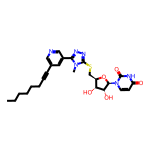
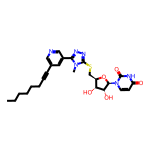
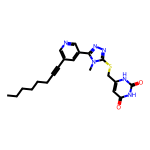
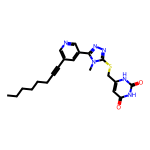
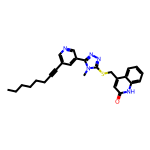
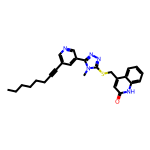
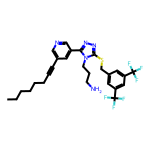
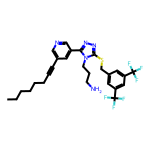
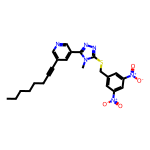
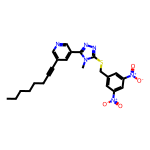
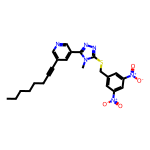
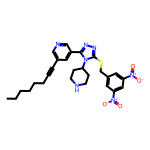
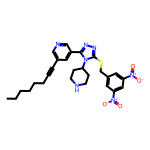
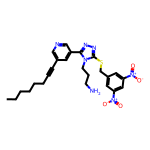
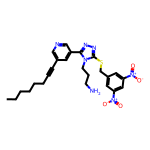
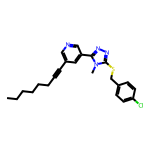
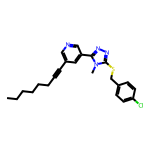
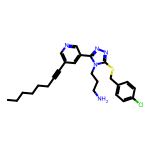
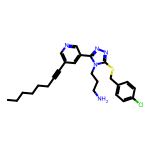
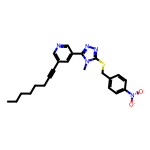
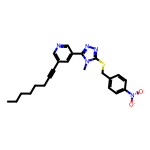
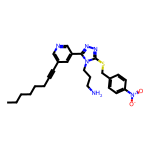
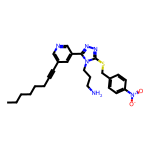
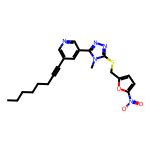
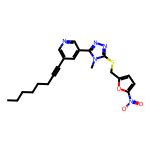
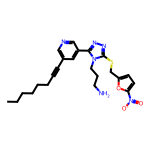
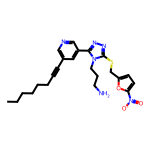
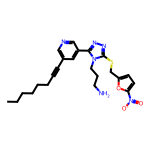
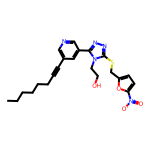
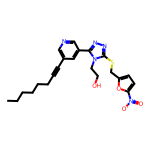
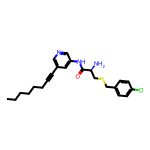
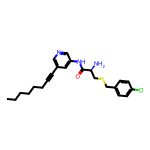
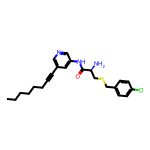
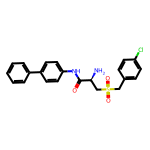
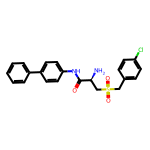
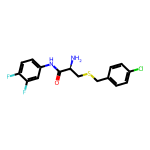
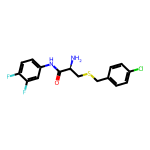
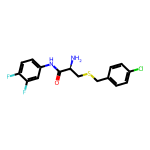
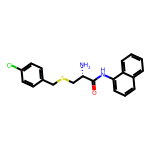
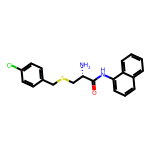

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from io import BytesIO
import base64
from IPython.display import display

# ----------------------------
# 1. Combine all series
# ----------------------------
series_dfs = [
    Series_A_Triazole,
    Series_B_Cysteine,
    Series_C_Spiro,
    Series_D_Pyrrolidine,
    Series_E_Spiro
]

combined_df = pd.concat(series_dfs, ignore_index=True)

# ----------------------------
# 2. Canonicalize SMILES
# ----------------------------
def canonicalize(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol, canonical=True)
    except:
        return None
    return None

combined_df['Canonical_SMILES'] = combined_df['Clean_SMILES'].apply(canonicalize)

# ----------------------------
# 3. Drop invalid SMILES
# ----------------------------
df = combined_df.dropna(subset=['Canonical_SMILES']).copy()

# ----------------------------
# 4. Find duplicates (all occurrences)
# ----------------------------
duplicates = df[df.duplicated(subset=['Canonical_SMILES'], keep=False)].copy()
duplicates.sort_values('Canonical_SMILES', inplace=True)

# ----------------------------
# 5. Create RDKit Mol objects
# ----------------------------
duplicates['Molecule'] = duplicates['Canonical_SMILES'].apply(Chem.MolFromSmiles)

# ----------------------------
# 6. Convert Mol objects to images for display in Jupyter
# ----------------------------
def mol_to_image_html(mol, size=(150,150)):
    if mol is None:
        return ""
    drawer = rdMolDraw2D.MolDraw2DCairo(size[0], size[1])
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    img_bytes = drawer.GetDrawingText()
    b64 = base64.b64encode(img_bytes).decode("utf-8")
    return f'<img src="data:image/png;base64,{b64}"/>'

duplicates['Mol_Image'] = duplicates['Molecule'].apply(mol_to_image_html)

# ----------------------------
# 7. Count duplicates
# ----------------------------
duplicates['Duplicate_Count'] = duplicates.groupby('Canonical_SMILES')['Canonical_SMILES'].transform('count')

# ----------------------------
# 8. Display dataframe in Jupyter
# ----------------------------
display(duplicates[['Canonical_SMILES','Duplicate_Count','Mol_Image']].style.format({'Mol_Image': lambda x: x}))

In [ ]:
unique_df=combined_df.drop_duplicates(subset=['Canonical_SMILES'])
unique_df

,Identifier,Series,Canonical SMILES,Canonical SMILES.1,IC50 uM,PIC50,Series_Name,Series_Code,Valid_SMILES,SMILES_Error,Clean_SMILES,Canonical_SMILES
0,TB-VS0012,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(Cl)C=C3)N2C)=...,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(Cl)C=C3)N2C)=...,5.3,5.275724,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Cl)cc3)n2C)c1,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Cl)cc3)n2C)c1
1,TB-VS12-2,A,BrC1=CC(C2=NN=C(N2C)S)=CN=C1,BrC1=CC(C2=NN=C(N2C)S)=CN=C1,200,3.698970,Series-A-Triazole,A,True,,Cn1c(S)nnc1-c1cncc(Br)c1,Cn1c(S)nnc1-c1cncc(Br)c1
2,TB-VS12-3,A,BrC1=CC(C2=NN=C(N2C)SCC3=CC=C(C=C3)Cl)=CN=C1,BrC1=CC(C2=NN=C(N2C)SCC3=CC=C(C=C3)Cl)=CN=C1,200,3.698970,Series-A-Triazole,A,True,,Cn1c(SCc2ccc(Cl)cc2)nnc1-c1cncc(Br)c1,Cn1c(SCc2ccc(Cl)cc2)nnc1-c1cncc(Br)c1
3,TB-VS12-4,A,CCCCCCC#CC1=CC(C2=NN=C(N2C)S)=CN=C1,CCCCCCC#CC1=CC(C2=NN=C(N2C)S)=CN=C1,22.57,4.646468,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(S)n2C)c1,CCCCCCC#Cc1cncc(-c2nnc(S)n2C)c1
4,TB-VS12-5,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=CC=C3)N2C)=CN=C1,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=CC=C3)N2C)=CN=C1,175,3.756962,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccccc3)n2C)c1,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccccc3)n2C)c1
...,...,...,...,...,...,...,...,...,...,...,...,...
177,ROY-0000287,C2,CCCCCCOC1CN(C2=CN=CC(N3CCC4(CN(C(OC(C)(C)C)=O)...,CCCCCCOC1CN(C2=CN=CC(N3CCC4(CN(C(OC(C)(C)C)=O)...,6.07,NaN,Series-E-Spiro,E,True,,CCCCCCOC1CN(c2cncc(N3CCC4(CN(C(=O)OC(C)(C)C)C4...,CCCCCCOC1CN(c2cncc(N3CCC4(CN(C(=O)OC(C)(C)C)C4...
178,ROY-0000286,C2,CC(OC(N1CC2(C1)CCN(C1=CC(N3CC(OCCCC4=CC=CC=C4)...,CC(OC(N1CC2(C1)CCN(C1=CC(N3CC(OCCCC4=CC=CC=C4)...,12.2,NaN,Series-E-Spiro,E,True,,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(N4CC(OCCCc5cccc...,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(N4CC(OCCCc5cccc...
179,ROY-0000277,C2,O=C(N1CC2(C1)CCN(C1=CC(C#CC3=CC=CC=C3)=CN=C1)C...,O=C(N1CC2(C1)CCN(C1=CC(C#CC3=CC=CC=C3)=CN=C1)C...,< 0.391,NaN,Series-E-Spiro,E,True,,O=C(c1cc([N+](=O)[O-])cc([N+](=O)[O-])c1)N1CC2...,O=C(c1cc([N+](=O)[O-])cc([N+](=O)[O-])c1)N1CC2...
180,ROY-0000275,C2,BrC1=CN=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=C1,BrC1=CN=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=C1,108,NaN,Series-E-Spiro,E,True,,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(Br)c3)C2)C1,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(Br)c3)C2)C1


### Removing data with non-numeric IC50

In [ ]:
import pandas as pd

# Identify rows where 'IC50 uM' is not numeric (these will be dropped)
non_numeric_rows = unique_df[pd.to_numeric(unique_df["IC50 uM"], errors="coerce").isna()].copy()

# Keep only numeric rows
numeric_df = unique_df[pd.to_numeric(unique_df["IC50 uM"], errors="coerce").notna()].copy()




In [ ]:
non_numeric_rows

,Identifier,Series,Canonical SMILES,Canonical SMILES.1,IC50 uM,PIC50,Series_Name,Series_Code,Valid_SMILES,SMILES_Error,Clean_SMILES,Canonical_SMILES
27,TB-VS12-29,A,CN1C(SCC2=CC=C(C=C2)N)=NN=C1C3=CN=CC(C#CCCCCCC...,CN1C(SCC2=CC=C(C=C2)N)=NN=C1C3=CN=CC(C#CCCCCCC...,NaN,NaN,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(N)cc3)n2C)c1,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(N)cc3)n2C)c1
78,TB-VS12-95,A,CN1C(C2=CC(OCCC)=CN=C2)=NN=C1SCC3=CC([N+]([O-]...,CN1C(C2=CC(OCCC)=CN=C2)=NN=C1SCC3=CC([N+]([O-]...,>100,NaN,Series-A-Triazole,A,True,,CCCOc1cncc(-c2nnc(SCc3cc([N+](=O)[O-])cc([N+](...,CCCOc1cncc(-c2nnc(SCc3cc([N+](=O)[O-])cc([N+](...
79,TB-VS12-96,A,CCCCCCC#CC1=CN=CC(C(N2C3CC3)=NN=C2SCC4=CC=C([N...,CCCCCCC#CC1=CN=CC(C(N2C3CC3)=NN=C2SCC4=CC=C([N...,>100,NaN,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc([N+](=O)[O-])o3...,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc([N+](=O)[O-])o3...
88,TB-VS12-105,A,ClC1=CC=C(C=C1)CSC2=NN=C(C3=CC(O)=CN=C3)N2C,ClC1=CC=C(C=C1)CSC2=NN=C(C3=CC(O)=CN=C3)N2C,NaN,NaN,Series-A-Triazole,A,True,,Cn1c(SCc2ccc(Cl)cc2)nnc1-c1cncc(O)c1,Cn1c(SCc2ccc(Cl)cc2)nnc1-c1cncc(O)c1
95,TB-VS12-114,A,CCCCCCC#CC1=CN=CC(C2=NN=C(SCC3=CC([N+]([O-])=O...,CCCCCCC#CC1=CN=CC(C2=NN=C(SCC3=CC([N+]([O-])=O...,NaN,NaN,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc([N+](=O)[O-])cc(...,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc([N+](=O)[O-])cc(...
136,TB-LCA-22,B,N[C@H](C(NC1=CC=CC=C1)=O)CSCC2=CC=C(Cl)C=C2,N[C@H](C(NC1=CC=CC=C1)=O)CSCC2=CC=C(Cl)C=C2,NaN,NaN,Series-B-Cysteine,B,True,,N[C@@H](CSCc1ccc(Cl)cc1)C(=O)Nc1ccccc1,N[C@@H](CSCc1ccc(Cl)cc1)C(=O)Nc1ccccc1
164,ROY-0000221-001,C,CCCCCCC#CC1=CN=CC(N2CCC3(CN(C(CCC4=CNC5=C4C=CC...,CCCCCCC#CC1=CN=CC(N2CCC3(CN(C(CCC4=CNC5=C4C=CC...,>200,NaN,Series-C-Spiro,C,True,,CCCCCCC#Cc1cncc(N2CCC3(CN(C(=O)CCc4c[nH]c5cccc...,CCCCCCC#Cc1cncc(N2CCC3(CN(C(=O)CCc4c[nH]c5cccc...
170,TB-VS12-110,D,O=C(N[C@H]1CN(C2=CC(C#CCCCCCC)=CN=C2)CC1)C3=CC...,O=C(N[C@H]1CN(C2=CC(C#CCCCCCC)=CN=C2)CC1)C3=CC...,NaN,NaN,Series-D-Pyrrolidine,D,True,,CCCCCCC#Cc1cncc(N2CC[C@@H](NC(=O)c3ccc(F)cc3)C...,CCCCCCC#Cc1cncc(N2CC[C@@H](NC(=O)c3ccc(F)cc3)C...
171,ROY-0000172-001,D,FC(OC(C=C1)=CC=C1CO[C@H](CC2)CN2C3=CC(C#CC4=CC...,FC(OC(C=C1)=CC=C1CO[C@H](CC2)CN2C3=CC(C#CC4=CC...,>200,NaN,Series-D-Pyrrolidine,D,True,,FC(F)(F)Oc1ccc(CO[C@@H]2CCN(c3cncc(C#Cc4ccccc4...,FC(F)(F)Oc1ccc(CO[C@@H]2CCN(c3cncc(C#Cc4ccccc4...
174,ROY-0000269,C2,CCCCCCC#CC1=CN=CC(N2CC[C@@H](OCC3=CC=C(OC(F)(F...,CCCCCCC#CC1=CN=CC(N2CC[C@@H](OCC3=CC=C(OC(F)(F...,> 200,NaN,Series-D-Pyrrolidine,D,True,,CCCCCCC#Cc1cncc(N2CC[C@@H](OCc3ccc(OC(F)(F)F)c...,CCCCCCC#Cc1cncc(N2CC[C@@H](OCc3ccc(OC(F)(F)F)c...


### Filter Non-Numeric IC50 Values

**Rationale:** Retain only rows with valid numeric IC50 measurements for regression modeling.

In [ ]:
numeric_df

,Identifier,Series,Canonical SMILES,Canonical SMILES.1,IC50 uM,PIC50,Series_Name,Series_Code,Valid_SMILES,SMILES_Error,Clean_SMILES,Canonical_SMILES
0,TB-VS0012,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(Cl)C=C3)N2C)=...,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(Cl)C=C3)N2C)=...,5.3,5.275724,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Cl)cc3)n2C)c1,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Cl)cc3)n2C)c1
1,TB-VS12-2,A,BrC1=CC(C2=NN=C(N2C)S)=CN=C1,BrC1=CC(C2=NN=C(N2C)S)=CN=C1,200,3.698970,Series-A-Triazole,A,True,,Cn1c(S)nnc1-c1cncc(Br)c1,Cn1c(S)nnc1-c1cncc(Br)c1
2,TB-VS12-3,A,BrC1=CC(C2=NN=C(N2C)SCC3=CC=C(C=C3)Cl)=CN=C1,BrC1=CC(C2=NN=C(N2C)SCC3=CC=C(C=C3)Cl)=CN=C1,200,3.698970,Series-A-Triazole,A,True,,Cn1c(SCc2ccc(Cl)cc2)nnc1-c1cncc(Br)c1,Cn1c(SCc2ccc(Cl)cc2)nnc1-c1cncc(Br)c1
3,TB-VS12-4,A,CCCCCCC#CC1=CC(C2=NN=C(N2C)S)=CN=C1,CCCCCCC#CC1=CC(C2=NN=C(N2C)S)=CN=C1,22.57,4.646468,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(S)n2C)c1,CCCCCCC#Cc1cncc(-c2nnc(S)n2C)c1
4,TB-VS12-5,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=CC=C3)N2C)=CN=C1,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=CC=C3)N2C)=CN=C1,175,3.756962,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccccc3)n2C)c1,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccccc3)n2C)c1
...,...,...,...,...,...,...,...,...,...,...,...,...
176,ROY-0000307,C2,BrC1=CC=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=N1,BrC1=CC=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=N1,63.6,NaN,Series-E-Spiro,E,True,,CC(C)(C)OC(=O)N1CC2(CCN(c3cccc(Br)n3)C2)C1,CC(C)(C)OC(=O)N1CC2(CCN(c3cccc(Br)n3)C2)C1
177,ROY-0000287,C2,CCCCCCOC1CN(C2=CN=CC(N3CCC4(CN(C(OC(C)(C)C)=O)...,CCCCCCOC1CN(C2=CN=CC(N3CCC4(CN(C(OC(C)(C)C)=O)...,6.07,NaN,Series-E-Spiro,E,True,,CCCCCCOC1CN(c2cncc(N3CCC4(CN(C(=O)OC(C)(C)C)C4...,CCCCCCOC1CN(c2cncc(N3CCC4(CN(C(=O)OC(C)(C)C)C4...
178,ROY-0000286,C2,CC(OC(N1CC2(C1)CCN(C1=CC(N3CC(OCCCC4=CC=CC=C4)...,CC(OC(N1CC2(C1)CCN(C1=CC(N3CC(OCCCC4=CC=CC=C4)...,12.2,NaN,Series-E-Spiro,E,True,,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(N4CC(OCCCc5cccc...,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(N4CC(OCCCc5cccc...
180,ROY-0000275,C2,BrC1=CN=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=C1,BrC1=CN=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=C1,108,NaN,Series-E-Spiro,E,True,,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(Br)c3)C2)C1,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(Br)c3)C2)C1


In [ ]:
# Select rows that will be dropped
dropped_rows = numeric_df[numeric_df["IC50 uM"].isin([100, 200])].copy()

# Drop them from the original dataframe
numeric_df = numeric_df.drop(dropped_rows.index)


In [ ]:
dropped_rows

,Identifier,Series,Canonical SMILES,Canonical SMILES.1,IC50 uM,PIC50,Series_Name,Series_Code,Valid_SMILES,SMILES_Error,Clean_SMILES,Canonical_SMILES
1,TB-VS12-2,A,BrC1=CC(C2=NN=C(N2C)S)=CN=C1,BrC1=CC(C2=NN=C(N2C)S)=CN=C1,200,3.69897,Series-A-Triazole,A,True,,Cn1c(S)nnc1-c1cncc(Br)c1,Cn1c(S)nnc1-c1cncc(Br)c1
2,TB-VS12-3,A,BrC1=CC(C2=NN=C(N2C)SCC3=CC=C(C=C3)Cl)=CN=C1,BrC1=CC(C2=NN=C(N2C)SCC3=CC=C(C=C3)Cl)=CN=C1,200,3.69897,Series-A-Triazole,A,True,,Cn1c(SCc2ccc(Cl)cc2)nnc1-c1cncc(Br)c1,Cn1c(SCc2ccc(Cl)cc2)nnc1-c1cncc(Br)c1
15,TB-VS12-17,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(O)C=C3)N2C)=C...,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(O)C=C3)N2C)=C...,200,3.69897,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(O)cc3)n2C)c1,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(O)cc3)n2C)c1
17,TB-VS12-19,A,ClC(C=C1)=CC=C1CSC2=NN=C(C3=CC=C(C#CCCCCCC)N=C...,ClC(C=C1)=CC=C1CSC2=NN=C(C3=CC=C(C#CCCCCCC)N=C...,200,3.69897,Series-A-Triazole,A,True,,CCCCCCC#Cc1ccc(-c2nnc(SCc3ccc(Cl)cc3)n2C)cn1,CCCCCCC#Cc1ccc(-c2nnc(SCc3ccc(Cl)cc3)n2C)cn1
18,TB-VS12-20,A,CN1C(C2=CN=CC(C#CCCCCCC)=C2)=NN=C1S(CC3=CC=C(C...,CN1C(C2=CN=CC(C#CCCCCCC)=C2)=NN=C1S(CC3=CC=C(C...,200,3.69897,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(S(=O)Cc3ccc(Cl)cc3)n2C)c1,CCCCCCC#Cc1cncc(-c2nnc(S(=O)Cc3ccc(Cl)cc3)n2C)c1
19,TB-VS12-21,A,ClC(C=C1)=CC=C1CSC(N2)=NN=C2C3=CN=CC(C#CCCCCCC...,ClC(C=C1)=CC=C1CSC(N2)=NN=C2C3=CN=CC(C#CCCCCCC...,200,3.69897,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Cl)cc3)[nH]2)c1,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Cl)cc3)[nH]2)c1
29,TB-VS12-31,A,ClC(C=C1)=CC=C1CSC2=NN=C(C3=CN=CC(C#CCCCCCC)=C...,ClC(C=C1)=CC=C1CSC2=NN=C(C3=CN=CC(C#CCCCCCC)=C...,200,3.69897,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Cl)cc3)o2)c1,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Cl)cc3)o2)c1
34,TB-VS12-37,A,ClC1=CC=C(CSC2=NN=C(N2CC3=CC=CC=C3)C4=CN=CC(C#...,ClC1=CC=C(CSC2=NN=C(N2CC3=CC=CC=C3)C4=CN=CC(C#...,200,3.69897,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Cl)cc3)n2Cc2ccc...,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Cl)cc3)n2Cc2ccc...
40,TB-VS12-43,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC(NC(N3)=O)=O)N2C...,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC(NC(N3)=O)=O)N2C...,200,3.69897,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(=O)[nH]c(=O)[nH]...,CCCCCCC#Cc1cncc(-c2nnc(SCc3cc(=O)[nH]c(=O)[nH]...
43,TB-VS12-46,A,CN1C(C2=CN=CC(C#CCCCCCC)=C2)=NN=C1SCC3=CC=C(Cl...,CN1C(C2=CN=CC(C#CCCCCCC)=C2)=NN=C1SCC3=CC=C(Cl...,200,3.69897,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Cl)cc3[N+](=O)[...,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Cl)cc3[N+](=O)[...


# Univariate Analysis on IC50

UNIVARIATE ANALYSIS: IC50 UΜ


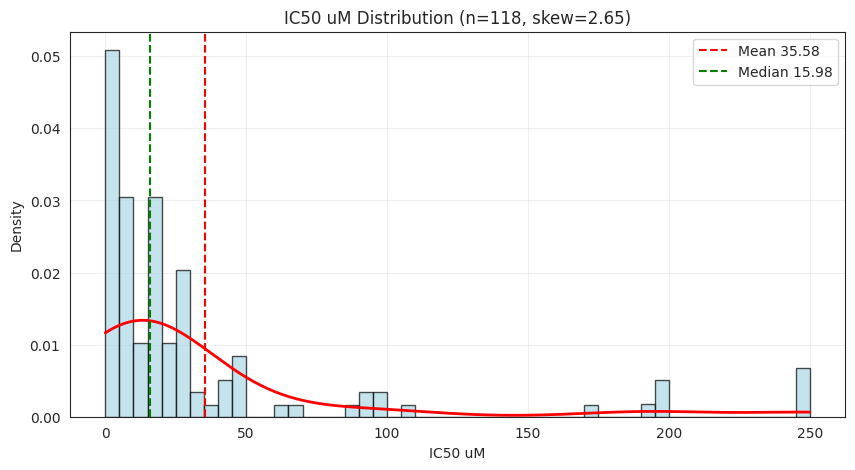

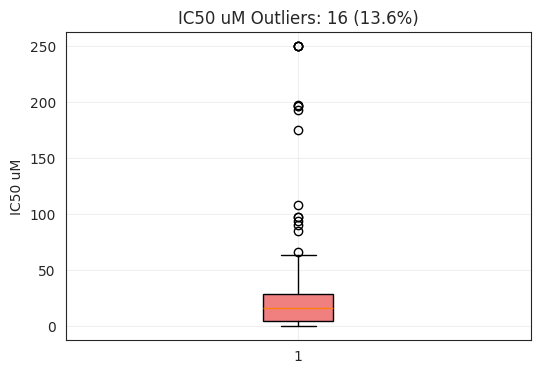


STATISTICAL SUMMARY
   Count    Mean  Median     Std    Min    Max    Range    Q1      Q3     IQR  \
0    118  35.576   15.98  57.633  0.048  250.0  249.952  5.08  29.095  24.016   

   Skewness  Kurtosis  Outliers  Outlier %  Normal p-value  Likely Normal  
0     2.649     6.388        16     13.559             0.0          False  

INSIGHTS & RECOMMENDATIONS
- Highly skewed — consider log transform.
- High outlier rate — consider robust models.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Column name
col = "IC50 uM"

# =============================
# CLEAN + CONVERT TO NUMERIC
# =============================
# Remove ">" or "<" signs if present (common in IC50 datasets)
numeric_df[col] = numeric_df[col].astype(str).str.replace(">", "", regex=False)
numeric_df[col] = numeric_df[col].astype(str).str.replace("<", "", regex=False)

# Convert to numeric safely
numeric_df[col] = pd.to_numeric(numeric_df[col], errors='coerce')

# Drop NaNs
data = numeric_df[col].dropna()

print("UNIVARIATE ANALYSIS: IC50 UΜ")
print("="*60)

# =============================
# HISTOGRAM + KDE + MEAN/MEDIAN
# =============================
plt.figure(figsize=(10,5))

# Histogram
plt.hist(data, bins=50, density=True, alpha=0.7,
         color='lightblue', edgecolor='black')

# KDE (if enough data)
if len(data) > 10:
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(data)
        x = np.linspace(data.min(), data.max(), 200)
        plt.plot(x, kde(x), 'r-', linewidth=2)
    except:
        pass

plt.axvline(data.mean(), color='red', linestyle='--', label=f"Mean {data.mean():.2f}")
plt.axvline(data.median(), color='green', linestyle='--', label=f"Median {data.median():.2f}")

plt.title(f"{col} Distribution (n={len(data)}, skew={data.skew():.2f})")
plt.xlabel(col)
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# =============================
# BOX PLOT + OUTLIER ANALYSIS
# =============================
plt.figure(figsize=(6,4))
bp = plt.boxplot(data, patch_artist=True)
bp['boxes'][0].set_facecolor('lightcoral')

Q1, Q3 = data.quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = data[(data < lower) | (data > upper)]
out_pct = len(outliers) * 100 / len(data)

plt.title(f"{col} Outliers: {len(outliers)} ({out_pct:.1f}%)")
plt.ylabel(col)
plt.grid(alpha=0.3)
plt.show()

# =============================
# STATISTICAL SUMMARY TABLE
# =============================
print("\nSTATISTICAL SUMMARY")
print("="*60)

row = {
    "Count": len(data),
    "Mean": data.mean(),
    "Median": data.median(),
    "Std": data.std(),
    "Min": data.min(),
    "Max": data.max(),
    "Range": data.max() - data.min(),
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "Skewness": data.skew(),
    "Kurtosis": data.kurtosis(),
    "Outliers": len(outliers),
    "Outlier %": out_pct
}

# Normality test (if enough samples)
if len(data) >= 8:
    stat, p = stats.normaltest(data)
    row["Normal p-value"] = p
    row["Likely Normal"] = p > 0.05
else:
    row["Normal p-value"] = np.nan
    row["Likely Normal"] = "Insufficient data"

summary_df = pd.DataFrame([row])
print(summary_df.round(3))

# =============================
# INSIGHTS & RECOMMENDATIONS
# =============================
print("\nINSIGHTS & RECOMMENDATIONS")
print("="*60)

skew = row["Skewness"]
std = row["Std"]
rng = row["Range"]

recommendations = []

# Skewness
if abs(skew) > 2:
    recommendations.append("Highly skewed — consider log transform.")
elif abs(skew) > 0.5:
    recommendations.append("Moderately skewed — consider a transform.")

# Outlier presence
if out_pct > 10:
    recommendations.append("High outlier rate — consider robust models.")
elif out_pct > 5:
    recommendations.append("Moderate number of outliers — evaluate model impact.")

# Range vs Std
if std > 0 and rng > 100 * std:
    recommendations.append("Very wide dynamic range — consider scaling.")

if not recommendations:
    recommendations.append("Data appears well-behaved.")

for r in recommendations:
    print("-", r)


### Univariate Statistical Analysis of IC50

**Purpose:** Comprehensive analysis of IC50 distribution to understand data characteristics for model selection and transformation decisions.

In [ ]:
!pip install umap-learn

In [ ]:
numeric_df['Canonical_SMILES'].isna().sum()

0

In [ ]:
from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

def standardize_mol(mol, verbose=False):
    from rdkit.Chem.MolStandardize import rdMolStandardize

    clean_mol = rdMolStandardize.Cleanup(mol)
    if verbose:
        print('Remove Hs, disconnect metal atoms, normalize the molecule, reionize the molecule:')

    parent_clean_mol = rdMolStandardize.FragmentParent(clean_mol)
    if verbose:
        print('Select the "parent" fragment:')

    uncharger = rdMolStandardize.Uncharger()
    uncharged_parent_clean_mol = uncharger.uncharge(parent_clean_mol)
    if verbose:
        print('Neutralize the molecule:')

    te = rdMolStandardize.TautomerEnumerator()
    taut_uncharged_parent_clean_mol = te.Canonicalize(uncharged_parent_clean_mol)
    if verbose:
        print('Enumerate tautomers:')
    assert taut_uncharged_parent_clean_mol is not None

    if verbose:
        print(Chem.MolToSmiles(taut_uncharged_parent_clean_mol))
    return taut_uncharged_parent_clean_mol

def standardize_smiles(smiles, verbose=False):
    """Standardize molecule without fixing protonation or nitro groups."""
    if verbose: print("Original:", smiles)

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        if verbose:
            print("Failed to parse SMILES:", smiles)
        return None

    std_mol = standardize_mol(mol, verbose=verbose)
    return Chem.MolToSmiles(std_mol)

def draw_mol_with_SVG(mol, molSize=(450,150)):
    """Draw RDKit molecule as SVG."""
    mc = Chem.Mol(mol.ToBinary())
    if not mc.GetNumConformers():
        rdDepictor.Compute2DCoords(mc)
    drawer = rdMolDraw2D.MolDraw2DSVG(molSize[0], molSize[1])
    drawer.DrawMolecule(mc)
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()
    display(SVG(svg.replace('svg:', '')))

### SMILES Standardization Functions

**Process:** Standardize SMILES to canonical representations including protonation fixes, salt removal, charge neutralization, and tautomer canonicalization.

In [ ]:
numeric_df['cleanedMol']=numeric_df['Canonical_SMILES'].apply(standardize_smiles, verbose=True)
dropped_rows['cleanedMol']=dropped_rows['Canonical_SMILES'].apply(standardize_smiles, verbose=True)
non_numeric_rows['cleanedMol']=non_numeric_rows['Canonical_SMILES'].apply(standardize_smiles, verbose=True)


In [ ]:
!pip install umap-learn

In [ ]:
numeric_df

,Identifier,Series,Canonical SMILES,Canonical SMILES.1,IC50 uM,PIC50,Series_Name,Series_Code,Valid_SMILES,SMILES_Error,Clean_SMILES,Canonical_SMILES,cleanedMol
0,TB-VS0012,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(Cl)C=C3)N2C)=...,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(Cl)C=C3)N2C)=...,5.300,5.275724,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Cl)cc3)n2C)c1,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Cl)cc3)n2C)c1,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Cl)cc3)n2C)c1
3,TB-VS12-4,A,CCCCCCC#CC1=CC(C2=NN=C(N2C)S)=CN=C1,CCCCCCC#CC1=CC(C2=NN=C(N2C)S)=CN=C1,22.570,4.646468,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(S)n2C)c1,CCCCCCC#Cc1cncc(-c2nnc(S)n2C)c1,CCCCCCC#Cc1cncc(-c2n[nH]c(=S)n2C)c1
4,TB-VS12-5,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=CC=C3)N2C)=CN=C1,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=CC=C3)N2C)=CN=C1,175.000,3.756962,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccccc3)n2C)c1,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccccc3)n2C)c1,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccccc3)n2C)c1
5,TB-VS12-6,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(Br)C=C3)N2C)=...,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(Br)C=C3)N2C)=...,4.594,5.337809,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Br)cc3)n2C)c1,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Br)cc3)n2C)c1,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Br)cc3)n2C)c1
6,TB-VS12-7,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(F)C=C3)N2C)=C...,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(F)C=C3)N2C)=C...,6.944,5.158390,Series-A-Triazole,A,True,,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(F)cc3)n2C)c1,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(F)cc3)n2C)c1,CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(F)cc3)n2C)c1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,ROY-0000307,C2,BrC1=CC=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=N1,BrC1=CC=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=N1,63.600,NaN,Series-E-Spiro,E,True,,CC(C)(C)OC(=O)N1CC2(CCN(c3cccc(Br)n3)C2)C1,CC(C)(C)OC(=O)N1CC2(CCN(c3cccc(Br)n3)C2)C1,CC(C)(C)OC(=O)N1CC2(CCN(c3cccc(Br)n3)C2)C1
177,ROY-0000287,C2,CCCCCCOC1CN(C2=CN=CC(N3CCC4(CN(C(OC(C)(C)C)=O)...,CCCCCCOC1CN(C2=CN=CC(N3CCC4(CN(C(OC(C)(C)C)=O)...,6.070,NaN,Series-E-Spiro,E,True,,CCCCCCOC1CN(c2cncc(N3CCC4(CN(C(=O)OC(C)(C)C)C4...,CCCCCCOC1CN(c2cncc(N3CCC4(CN(C(=O)OC(C)(C)C)C4...,CCCCCCOC1CN(c2cncc(N3CCC4(CN(C(=O)OC(C)(C)C)C4...
178,ROY-0000286,C2,CC(OC(N1CC2(C1)CCN(C1=CC(N3CC(OCCCC4=CC=CC=C4)...,CC(OC(N1CC2(C1)CCN(C1=CC(N3CC(OCCCC4=CC=CC=C4)...,12.200,NaN,Series-E-Spiro,E,True,,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(N4CC(OCCCc5cccc...,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(N4CC(OCCCc5cccc...,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(N4CC(OCCCc5cccc...
180,ROY-0000275,C2,BrC1=CN=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=C1,BrC1=CN=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=C1,108.000,NaN,Series-E-Spiro,E,True,,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(Br)c3)C2)C1,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(Br)c3)C2)C1,CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(Br)c3)C2)C1


Valid molecules: 118


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/

Best HDBSCAN min_cluster_size: 10, silhouette: 0.790
   min_size  n_clusters  silhouette_score
0        10           2          0.790335
1        20           2          0.790335
2        30           2          0.790335


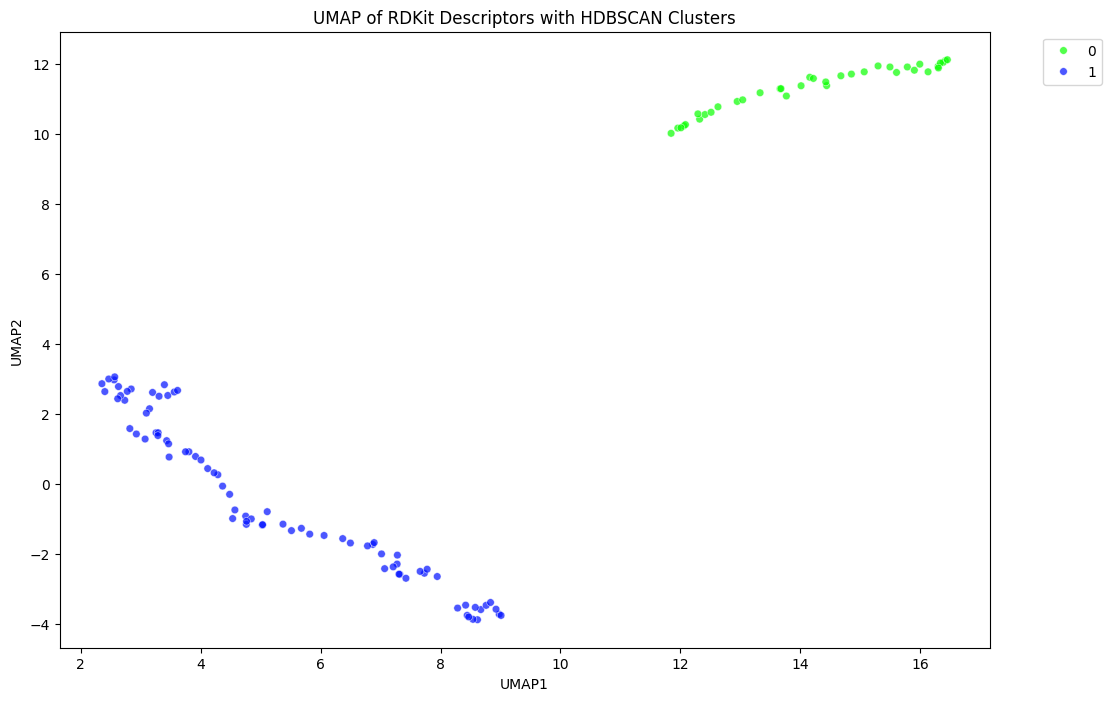

Number of outlier molecules: 0
Empty DataFrame
Columns: [cleanedMol, Scaffold]
Index: []
Cluster 0: 37 molecules
Cluster 1: 81 molecules


In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
import umap.umap_ as umap
import hdbscan
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 0. Check column exists
# -----------------------------
if 'cleanedMol' not in numeric_df.columns:
    raise ValueError("Column 'cleanedMol' not found in numeric_df")

# -----------------------------
# 1. Convert SMILES → Molecule safely
# -----------------------------
def safe_mol_from_smiles(smi):
    if isinstance(smi, str) and smi.strip():  # must be non-empty string
        mol = Chem.MolFromSmiles(smi)
        return mol
    return None

numeric_df['Molecule'] = numeric_df['cleanedMol'].apply(safe_mol_from_smiles)
numeric_df = numeric_df[numeric_df['Molecule'].notna()].reset_index(drop=True)
print(f"Valid molecules: {len(numeric_df)}")

# -----------------------------
# 2. RDKit Descriptors
# -----------------------------
descriptor_list = [desc[0] for desc in Descriptors._descList]  # all RDKit descriptors

def calc_rdkit_descriptors(mol):
    try:
        values = [desc(mol) if mol is not None else np.nan for name, desc in Descriptors._descList]
        return np.array(values, dtype=float)
    except:
        return np.array([np.nan]*len(descriptor_list), dtype=float)

numeric_df['Descriptors'] = numeric_df['Molecule'].apply(calc_rdkit_descriptors)
descriptor_matrix = np.stack(numeric_df['Descriptors'].values)

# Optional: remove descriptors with NaNs or constant values
mask = np.all(np.isfinite(descriptor_matrix), axis=0) & (np.std(descriptor_matrix, axis=0) > 0)
descriptor_matrix = descriptor_matrix[:, mask]

# -----------------------------
# 3. UMAP (2D)
# -----------------------------
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric='euclidean',  # continuous descriptors
    random_state=42
)
umap_result = umap_model.fit_transform(descriptor_matrix)
numeric_df['UMAP1'] = umap_result[:, 0]
numeric_df['UMAP2'] = umap_result[:, 1]

# -----------------------------
# 4. HDBSCAN tuning
# -----------------------------
best_clusters = None
best_score = -1
best_min_size = None
results = []

for min_size in [10, 20, 30, 50, 75, 100]:
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_size, metric='euclidean')
    labels = clusterer.fit_predict(umap_result)

    # skip if no clusters
    if len(set(labels)) <= 1 or set(labels) == {-1}:
        continue

    mask = labels != -1
    if sum(mask) < 2:
        continue

    score = silhouette_score(umap_result[mask], labels[mask])
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    results.append((min_size, n_clusters, score))

    if score > best_score:
        best_score = score
        best_clusters = labels
        best_min_size = min_size

numeric_df['Cluster'] = best_clusters
print(f"Best HDBSCAN min_cluster_size: {best_min_size}, silhouette: {best_score:.3f}")

# Optional: show all tuning results
results_df = pd.DataFrame(results, columns=['min_size','n_clusters','silhouette_score'])
print(results_df.sort_values('silhouette_score', ascending=False))

# -----------------------------
# 5. Scaffold extraction
# -----------------------------
def get_scaffold_safe(mol):
    try:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold)
    except:
        return None

numeric_df['Scaffold'] = numeric_df['Molecule'].apply(get_scaffold_safe)

# -----------------------------
# 6. Visualization
# -----------------------------
plt.figure(figsize=(12, 8))
unique_clusters = sorted(set(best_clusters))
palette = sns.color_palette("hsv", len(unique_clusters))

sns.scatterplot(
    x='UMAP1', y='UMAP2',
    hue='Cluster',
    data=numeric_df,
    palette=palette,
    s=30,
    alpha=0.7,
    legend='full'
)
plt.title("UMAP of RDKit Descriptors with HDBSCAN Clusters")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

# -----------------------------
# 7. Outliers
# -----------------------------
outliers = numeric_df[numeric_df['Cluster'] == -1]
print(f"Number of outlier molecules: {len(outliers)}")
print(outliers[['cleanedMol', 'Scaffold']].head())

# -----------------------------
# 8. Cluster summary
# -----------------------------
for cluster_id in unique_clusters:
    if cluster_id == -1:
        continue
    cluster_size = sum(best_clusters == cluster_id)
    print(f"Cluster {cluster_id}: {cluster_size} molecules")


In [ ]:
!pip install alphashape shapely

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.6/507.6 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.5/740.5 kB 15.8 MB/s eta 0:00:00


Valid molecules: 118
Descriptor matrix shape: (118, 164)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/

Best min_cluster_size: 10
Silhouette score: 0.79

Series distribution inside islands:

   Cluster Series_Code  Count
1        0           B     22
0        0           A      8
4        0           E      4
3        0           D      2
2        0           C      1
5        1           A     66
6        1           B      6
7        1           C      4
8        1           D      3
9        1           E      2

Cluster vs Series table:

Series_Code   A   B  C  D  E
Cluster                     
0             8  22  1  2  4
1            66   6  4  3  2

Cluster composition (%):

Series_Code      A      B     C     D      E
Cluster                                     
0            21.62  59.46  2.70  5.41  10.81
1            81.48   7.41  4.94  3.70   2.47


TypeError: 'MultiPoint' object is not iterable

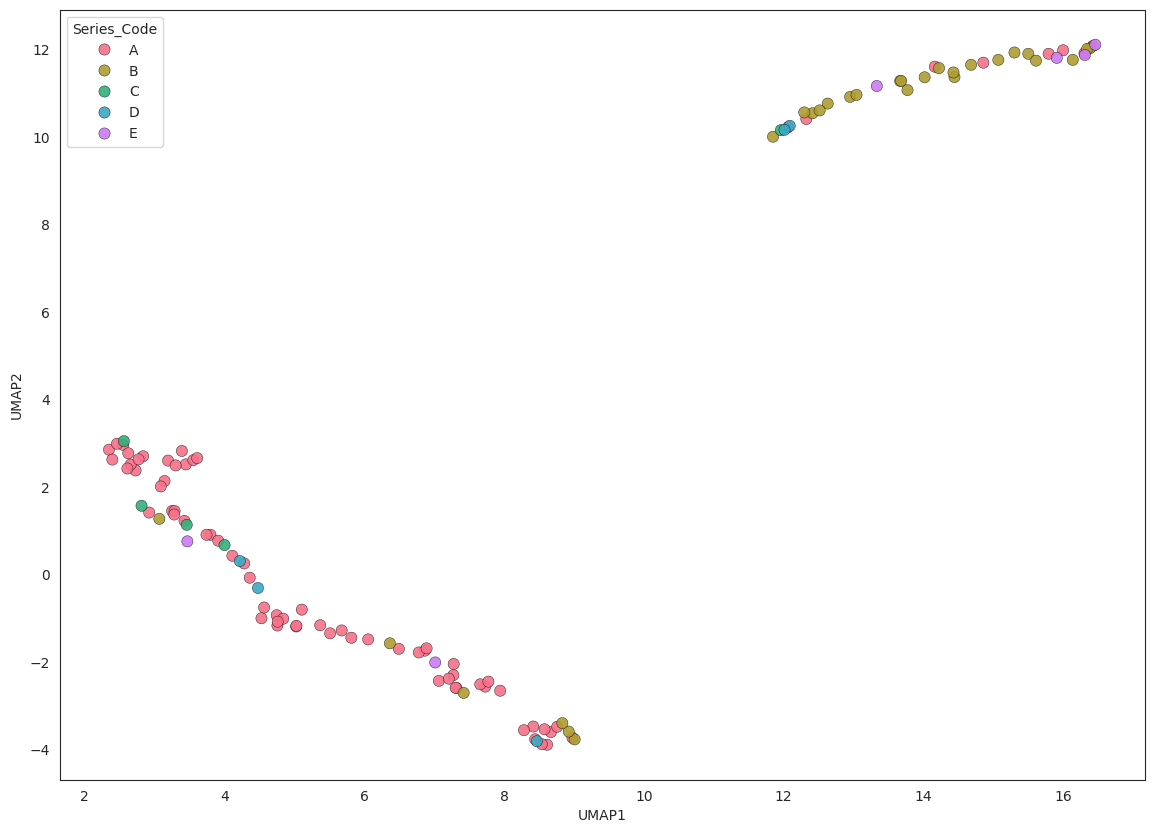

In [ ]:
# ==========================================
# Chemical Space Analysis + Island Detection
# ==========================================

import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

import umap.umap_ as umap
import hdbscan

from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

import alphashape
from shapely.geometry import Polygon

# ------------------------------------------------
# 1. Validate columns
# ------------------------------------------------
required_cols = ["cleanedMol", "Series_Code"]

for col in required_cols:
    if col not in numeric_df.columns:
        raise ValueError(f"{col} missing from dataframe")

# ------------------------------------------------
# 2. Convert SMILES → Molecules
# ------------------------------------------------
def safe_mol(smi):

    if isinstance(smi, str) and smi.strip():
        return Chem.MolFromSmiles(smi)

    return None


numeric_df["Molecule"] = numeric_df["cleanedMol"].apply(safe_mol)

numeric_df = numeric_df[numeric_df["Molecule"].notna()].reset_index(drop=True)

print("Valid molecules:", len(numeric_df))

# ------------------------------------------------
# 3. Compute RDKit descriptors
# ------------------------------------------------
descriptor_list = [d[0] for d in Descriptors._descList]

def calc_desc(mol):

    try:
        return np.array([desc(mol) for name, desc in Descriptors._descList])
    except:
        return np.array([np.nan] * len(descriptor_list))


numeric_df["Descriptors"] = numeric_df["Molecule"].apply(calc_desc)

descriptor_matrix = np.stack(numeric_df["Descriptors"].values)

mask = np.all(np.isfinite(descriptor_matrix), axis=0) & (np.std(descriptor_matrix, axis=0) > 0)

descriptor_matrix = descriptor_matrix[:, mask]

print("Descriptor matrix shape:", descriptor_matrix.shape)

# ------------------------------------------------
# 4. UMAP dimensionality reduction
# ------------------------------------------------
umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    n_components=2,
    random_state=42
)

umap_result = umap_model.fit_transform(descriptor_matrix)

numeric_df["UMAP1"] = umap_result[:, 0]
numeric_df["UMAP2"] = umap_result[:, 1]

# ------------------------------------------------
# 5. HDBSCAN clustering with tuning
# ------------------------------------------------
best_labels = None
best_score = -1
best_size = None

for size in [10,20,30,50,75,100]:

    clusterer = hdbscan.HDBSCAN(min_cluster_size=size)

    labels = clusterer.fit_predict(umap_result)

    if len(set(labels)) <= 1:
        continue

    mask = labels != -1

    if sum(mask) < 2:
        continue

    score = silhouette_score(umap_result[mask], labels[mask])

    if score > best_score:
        best_score = score
        best_labels = labels
        best_size = size

numeric_df["Cluster"] = best_labels

print("Best min_cluster_size:", best_size)
print("Silhouette score:", round(best_score,3))

# ------------------------------------------------
# 6. Murcko scaffold extraction
# ------------------------------------------------
def get_scaffold(mol):

    try:
        scaf = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaf)
    except:
        return None


numeric_df["Scaffold"] = numeric_df["Molecule"].apply(get_scaffold)

# ------------------------------------------------
# 7. Compute cluster composition
# ------------------------------------------------

cluster_series_counts = (
    numeric_df
    .groupby(["Cluster","Series_Code"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Cluster","Count"], ascending=[True,False])
)

print("\nSeries distribution inside islands:\n")
print(cluster_series_counts)

# Pivot table
cluster_series_table = pd.crosstab(
    numeric_df["Cluster"],
    numeric_df["Series_Code"]
)

print("\nCluster vs Series table:\n")
print(cluster_series_table)

# Percent composition
cluster_series_percent = cluster_series_table.div(
    cluster_series_table.sum(axis=1),
    axis=0
) * 100

print("\nCluster composition (%):\n")
print(cluster_series_percent.round(2))

# ------------------------------------------------
# 8. Dominant Series_Code per cluster
# ------------------------------------------------
dominant_series = (
    numeric_df
    .groupby(["Cluster","Series_Code"])
    .size()
    .reset_index(name="count")
    .sort_values(["Cluster","count"], ascending=[True,False])
    .drop_duplicates("Cluster")
)

dominant_series_dict = dict(
    zip(dominant_series["Cluster"], dominant_series["Series_Code"])
)

# ------------------------------------------------
# 9. Visualization
# ------------------------------------------------
sns.set_style("white")

fig, ax = plt.subplots(figsize=(14,10))

palette = sns.color_palette("husl", numeric_df["Series_Code"].nunique())

sns.scatterplot(
    x="UMAP1",
    y="UMAP2",
    hue="Series_Code",
    palette=palette,
    data=numeric_df,
    s=65,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.9,
    ax=ax
)

# ------------------------------------------------
# 10. Draw curved cluster islands (alpha shapes)
# ------------------------------------------------
for cluster_id in sorted(numeric_df["Cluster"].unique()):

    if cluster_id == -1:
        continue

    cluster_points = numeric_df[
        numeric_df["Cluster"] == cluster_id
    ][["UMAP1","UMAP2"]].values

    if len(cluster_points) < 10:
        continue

    alpha = alphashape.optimizealpha(cluster_points)

    hull = alphashape.alphashape(cluster_points, alpha)

    if isinstance(hull, Polygon):

        x,y = hull.exterior.xy

        ax.fill(
            x,
            y,
            alpha=0.15,
            color="black",
            linewidth=2
        )

# ------------------------------------------------
# 11. Island labels (dominant Series_Code)
# ------------------------------------------------
for cluster_id in sorted(numeric_df["Cluster"].unique()):

    if cluster_id == -1:
        continue

    subset = numeric_df[numeric_df["Cluster"] == cluster_id]

    cx = subset["UMAP1"].mean()
    cy = subset["UMAP2"].mean()

    label = dominant_series_dict.get(cluster_id, "Unknown")

    ax.text(
        cx,
        cy,
        f"{label}",
        fontsize=13,
        weight="bold",
        ha="center",
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.8)
    )

# ------------------------------------------------
# 12. Final plot styling
# ------------------------------------------------
ax.set_title(
    "Chemical Space Map (UMAP + HDBSCAN)",
    fontsize=18,
    weight="bold"
)

ax.set_xlabel("UMAP 1", fontsize=14)
ax.set_ylabel("UMAP 2", fontsize=14)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    title="Series_Code"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------
# 13. Outliers
# ------------------------------------------------
outliers = numeric_df[numeric_df["Cluster"] == -1]

print("\nNumber of outliers:", len(outliers))

print(outliers[["cleanedMol","Series_Code","Scaffold"]].head())

### RDKit Descriptors and Chemical Space Clustering

**Feature Generation:** Calculate all RDKit 2D descriptors for each molecule, providing interpretable physical-chemical properties.

**Quality Control:** Remove descriptors with missing values or zero variance to ensure robust feature matrix.

**Chemical Space Analysis:**
- UMAP dimensionality reduction with Euclidean distance (for continuous descriptors)
- HDBSCAN clustering for structural grouping
- Scaffold extraction for chemical interpretation

**Application:** Enables scaffold-based cross-validation and chemical space visualization.

In [ ]:
numeric_df['transformed_IC50'] = np.log10(numeric_df['IC50 uM'] + 1e-8)

## AutoML - Model - Based Upon Circular Fingerprint

In [ ]:
df=numeric_df

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors

# -----------------------------
# Function to calculate RDKit descriptors
# -----------------------------
descriptor_names = [name for name, func in Descriptors._descList]

def calculate_rdkit_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [np.nan] * len(descriptor_names)
    return [func(mol) for name, func in Descriptors._descList]

# -----------------------------
# Apply to DataFrame
# -----------------------------
descriptor_array = np.vstack(df['cleanedMol'].apply(calculate_rdkit_descriptors))

# Convert to DataFrame
desc_df = pd.DataFrame(descriptor_array, columns=descriptor_names)

# Merge with original DataFrame
df = pd.concat([df.reset_index(drop=True), desc_df.reset_index(drop=True)], axis=1)

print(f"Generated {desc_df.shape[1]} RDKit descriptors for {df.shape[0]} molecules.")


Generated 217 RDKit descriptors for 118 molecules.


In [ ]:
df

,Identifier,Series,Canonical SMILES,Canonical SMILES.1,IC50 uM,PIC50,Series_Name,Series_Code,Valid_SMILES,SMILES_Error,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,TB-VS0012,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(Cl)C=C3)N2C)=...,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(Cl)C=C3)N2C)=...,5.3,5.275724,Series-A-Triazole,A,True,,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
1,TB-VS12-4,A,CCCCCCC#CC1=CC(C2=NN=C(N2C)S)=CN=C1,CCCCCCC#CC1=CC(C2=NN=C(N2C)S)=CN=C1,22.57,4.646468,Series-A-Triazole,A,True,,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,TB-VS12-5,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=CC=C3)N2C)=CN=C1,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=CC=C3)N2C)=CN=C1,175,3.756962,Series-A-Triazole,A,True,,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
3,TB-VS12-6,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(Br)C=C3)N2C)=...,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(Br)C=C3)N2C)=...,4.594,5.337809,Series-A-Triazole,A,True,,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
4,TB-VS12-7,A,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(F)C=C3)N2C)=C...,CCCCCCC#CC1=CC(C2=NN=C(SCC3=CC=C(F)C=C3)N2C)=C...,6.944,5.158390,Series-A-Triazole,A,True,,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,ROY-0000307,C2,BrC1=CC=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=N1,BrC1=CC=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=N1,63.6,NaN,Series-E-Spiro,E,True,,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
114,ROY-0000287,C2,CCCCCCOC1CN(C2=CN=CC(N3CCC4(CN(C(OC(C)(C)C)=O)...,CCCCCCOC1CN(C2=CN=CC(N3CCC4(CN(C(OC(C)(C)C)=O)...,6.07,NaN,Series-E-Spiro,E,True,,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
115,ROY-0000286,C2,CC(OC(N1CC2(C1)CCN(C1=CC(N3CC(OCCCC4=CC=CC=C4)...,CC(OC(N1CC2(C1)CCN(C1=CC(N3CC(OCCCC4=CC=CC=C4)...,12.2,NaN,Series-E-Spiro,E,True,,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
116,ROY-0000275,C2,BrC1=CN=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=C1,BrC1=CN=CC(N2CCC3(CN(C(OC(C)(C)C)=O)C3)C2)=C1,108,NaN,Series-E-Spiro,E,True,,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
feature1=df.iloc[:, 16:]

In [ ]:
feature1

,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0.746421,0.247066,10.586207,425.001,399.801,424.148845,150.0,0.0,0.191056,-0.305128,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
1,0.580936,0.522065,10.238095,300.431,280.271,300.140868,110.0,0.0,0.187645,-0.305345,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,0.814498,0.289674,10.500000,390.556,364.348,390.187818,144.0,0.0,0.191056,-0.305128,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
3,0.807780,0.222138,10.586207,469.452,444.252,468.098330,150.0,0.0,0.191056,-0.305128,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
4,-0.225801,0.275188,10.586207,408.546,383.346,408.178396,150.0,0.0,0.191056,-0.305128,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,-0.428786,0.714024,20.181818,368.275,346.099,367.089539,120.0,0.0,0.409821,-0.443688,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
114,-0.440858,0.556955,20.437500,444.620,404.300,444.310041,178.0,0.0,0.409821,-0.443688,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
115,-0.447695,0.551181,19.571429,478.637,440.333,478.294391,188.0,0.0,0.409821,-0.443688,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
116,-0.427051,0.763287,20.181818,368.275,346.099,367.089539,120.0,0.0,0.409821,-0.443688,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
target=df['transformed_IC50']
target.head()

,transformed_IC50
0,0.724276
3,1.353532
4,2.243038
5,0.662191
6,0.841610


In [ ]:

# RDKit (for Colab, use the conda-free wheel)
!pip install rdkit

# Mordred descriptors
!pip install mordred

# Scikit-learn
!pip install scikit-learn

# Machine learning libraries
!pip install xgboost lightgbm catboost optuna

# Joblib for saving/loading models
!pip install joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 33.9 MB/s eta 0:00:00


#Best_dev

[17:49:35] DEPRECATION WARNING: please use MorganGenerator
[17:49:35] DEPRECATION WARNING: please use MorganGenerator
[17:49:35] DEPRECATION WARNING: please use MorganGenerator
[17:49:35] DEPRECATION WARNING: please use MorganGenerator
[17:49:35] DEPRECATION WARNING: please use MorganGenerator
[17:49:35] DEPRECATION WARNING: please use MorganGenerator
[17:49:35] DEPRECATION WARNING: please use MorganGenerator
[17:49:35] DEPRECATION WARNING: please use MorganGenerator
[17:49:35] DEPRECATION WARNING: please use MorganGenerator
[17:49:35] DEPRECATION WARNING: please use MorganGenerator
[17:49:35] DEPRECATION WARNING: please use MorganGenerator
[17:49:35] DEPRECATION WARNING: please use MorganGenerator
[17:49:35] DEPRECATION WARNING: please use MorganGenerator
[17:49:35] DEPRECATION WARNING: please use MorganGenerator
[17:49:35] DEPRECATION WARNING: please use MorganGenerator
[17:49:35] DEPRECATION WARNING: please use MorganGenerator
[17:49:35] DEPRECATION WARNING: please use MorganGenerat

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000410 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2833
[LightGBM] [Info] Number of data points in the train set: 107, number of used features: 134
[LightGBM] [Info] Start training from score 1.135836
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

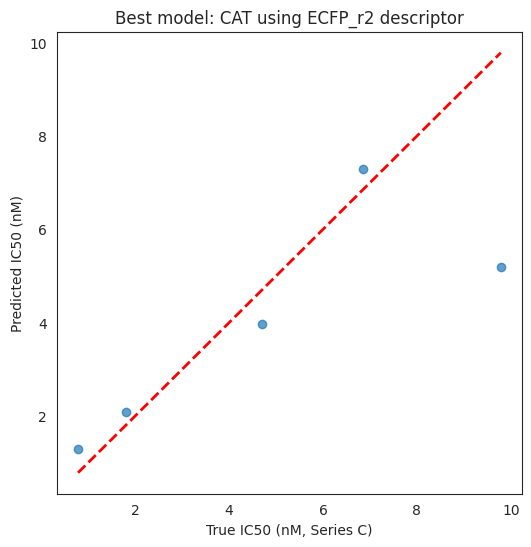

✅ Pipeline complete. All predictions saved. Plot generated for test set!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, MACCSkeys
from mordred import Calculator, descriptors

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score

from sklearn.linear_model import (
    Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
)
from sklearn.neural_network import MLPRegressor

import xgboost as xgb
import lightgbm as lgb
import catboost as cat
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# =========================
# Dataset split
# =========================
train_df = numeric_df[numeric_df["Series_Code"].isin(["A","B","D"])].reset_index(drop=True)
test_df = numeric_df[numeric_df["Series_Code"] == "C"].reset_index(drop=True)
predict_df = numeric_df[numeric_df["Series_Code"] == "E"].reset_index(drop=True)

smiles_train = train_df["cleanedMol"].values
y_train = train_df["transformed_IC50"].values
smiles_test = test_df["cleanedMol"].values
y_test = test_df["transformed_IC50"].values
smiles_predict = predict_df["cleanedMol"].values
smiles_dropped = dropped_rows["cleanedMol"].values if not dropped_rows.empty else np.array([])
smiles_non_numeric = non_numeric_rows["cleanedMol"].values if not non_numeric_rows.empty else np.array([])

# =========================
# Descriptor functions
# =========================
def rdkit_desc(s):
    m = Chem.MolFromSmiles(s)
    return [f(m) if m else np.nan for _, f in Descriptors._descList]

def ecfp(s, radius, nBits=2048):
    m = Chem.MolFromSmiles(s)
    if not m:
        return np.zeros(nBits)
    fp = AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits)
    arr = np.zeros(nBits)
    from rdkit.DataStructs import ConvertToNumpyArray
    ConvertToNumpyArray(fp, arr)
    return arr

def maccs(s):
    m = Chem.MolFromSmiles(s)
    return np.array(MACCSkeys.GenMACCSKeys(m)) if m else np.zeros(167)

calc = Calculator(descriptors, ignore_3D=True)
def mordred_desc(s):
    m = Chem.MolFromSmiles(s)
    return calc(m) if m else np.zeros(len(calc.descriptors))

def compute_descriptors(smiles_list):
    return {
        "RDKit": np.array([rdkit_desc(s) for s in smiles_list]),
        "ECFP_r1": np.array([ecfp(s, 1) for s in smiles_list]),
        "ECFP_r2": np.array([ecfp(s, 2) for s in smiles_list]),
        "ECFP_r3": np.array([ecfp(s, 3) for s in smiles_list]),
        "MACCS": np.array([maccs(s) for s in smiles_list]),
        "Mordred": pd.DataFrame([mordred_desc(s) for s in smiles_list]).fillna(0).values
    }

# =========================
# Compute descriptors
# =========================
X_train_raw = compute_descriptors(smiles_train)
X_test_raw = compute_descriptors(smiles_test)
X_predict_raw = compute_descriptors(smiles_predict)
X_dropped_raw = compute_descriptors(smiles_dropped)
X_non_numeric_raw = compute_descriptors(smiles_non_numeric)

# =========================
# Models
# =========================
model_factories = {
    "RF": lambda p: RandomForestRegressor(**p, random_state=42),
    "ET": lambda p: ExtraTreesRegressor(**p, random_state=42),
    "GB": lambda p: GradientBoostingRegressor(**p, random_state=42),
    "XGB": lambda p: xgb.XGBRegressor(**p, random_state=42, n_jobs=-1),
    "LGBM": lambda p: lgb.LGBMRegressor(**p, random_state=42),
    "CAT": lambda p: cat.CatBoostRegressor(**p, random_state=42, verbose=0, loss_function='RMSE'),
    "SVR": lambda p: SVR(**p),
    "KNN": lambda p: KNeighborsRegressor(**p),
    "MLP": lambda p: MLPRegressor(hidden_layer_sizes=(100,50), max_iter=500),
    "Ridge": lambda p: Ridge(),
    "Lasso": lambda p: Lasso(),
    "ElasticNet": lambda p: ElasticNet(),
    "BayesianRidge": lambda p: BayesianRidge(),
    "Huber": lambda p: HuberRegressor(),
    "DT": lambda p: DecisionTreeRegressor(random_state=42)
}

scaled_models = {"SVR","KNN","MLP","Ridge","Lasso","ElasticNet","BayesianRidge","Huber"}

# =========================
# Training loop
# =========================
trained_models = {}
imputers = {}
scalers = {}
results = []

for desc_name in X_train_raw:
    imp = SimpleImputer(strategy="mean")
    X_train = imp.fit_transform(X_train_raw[desc_name])
    X_test = imp.transform(X_test_raw[desc_name])
    X_predict = imp.transform(X_predict_raw[desc_name])
    X_dropped = imp.transform(X_dropped_raw[desc_name]) if len(smiles_dropped)>0 else np.array([])
    X_non_numeric = imp.transform(X_non_numeric_raw[desc_name]) if len(smiles_non_numeric)>0 else np.array([])
    imputers[desc_name] = imp

    for model_name in model_factories:
        X_tr, X_te, X_pr = X_train.copy(), X_test.copy(), X_predict.copy()
        sc = None
        if model_name in scaled_models:
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)
            X_pr = sc.transform(X_pr)
            if len(X_dropped)>0:
                X_dropped = sc.transform(X_dropped)
            if len(X_non_numeric)>0:
                X_non_numeric = sc.transform(X_non_numeric)
            scalers[(desc_name, model_name)] = sc

        model = model_factories[model_name]({})
        model.fit(X_tr, y_train)
        trained_models[(desc_name, model_name)] = model

        y_te_pred = model.predict(X_te)
        r2 = r2_score(y_test, y_te_pred)
        results.append({"Descriptor": desc_name, "Model": model_name, "R2": r2})

# =========================
# Best model selection
# =========================
results_df = pd.DataFrame(results)
best_model_row = results_df.loc[results_df["R2"].idxmax()]
best_desc = best_model_row["Descriptor"]
best_model_name = best_model_row["Model"]
print(f"Best model: {best_model_name} using {best_desc} descriptor")

# =========================
# Helper for prediction + anti-log
# =========================
def predict_and_antilog(model, X, df_original):
    y_pred_log = model.predict(X)
    y_pred = 10 ** y_pred_log
    df = df_original.copy()
    df["Predicted_IC50"] = y_pred
    return df

# =========================
# Transform data for best model
# =========================
imp_best = imputers[best_desc]
X_predict_best = imp_best.transform(X_predict_raw[best_desc])
X_test_best = imp_best.transform(X_test_raw[best_desc])
X_dropped_best = imp_best.transform(X_dropped_raw[best_desc]) if len(smiles_dropped)>0 else np.array([])
X_non_numeric_best = imp_best.transform(X_non_numeric_raw[best_desc]) if len(smiles_non_numeric)>0 else np.array([])

sc_best = scalers.get((best_desc, best_model_name), None)
if sc_best:
    X_predict_best = sc_best.transform(X_predict_best)
    X_test_best = sc_best.transform(X_test_best)
    if len(X_dropped_best)>0:
        X_dropped_best = sc_best.transform(X_dropped_best)
    if len(X_non_numeric_best)>0:
        X_non_numeric_best = sc_best.transform(X_non_numeric_best)

model_best = trained_models[(best_desc, best_model_name)]

# =========================
# Predictions
# =========================
pred_E_df = predict_and_antilog(model_best, X_predict_best, predict_df)
pred_test_df = predict_and_antilog(model_best, X_test_best, test_df)
pred_dropped_df = predict_and_antilog(model_best, X_dropped_best, dropped_rows) if len(smiles_dropped)>0 else pd.DataFrame()
pred_non_numeric_df = predict_and_antilog(model_best, X_non_numeric_best, non_numeric_rows) if len(smiles_non_numeric)>0 else pd.DataFrame()

# =========================
# Save predictions
# =========================
pred_E_df.to_csv("SeriesE_with_predictions.csv", index=False)
pred_test_df.to_csv("SeriesC_test_with_predictions.csv", index=False)
if not pred_dropped_df.empty:
    pred_dropped_df.to_csv("Dropped_rows_predictions.csv", index=False)
if not pred_non_numeric_df.empty:
    pred_non_numeric_df.to_csv("Non_numeric_rows_predictions.csv", index=False)

# =========================
# y_true vs y_pred plot for test set
# =========================
y_test_orig = 10 ** y_test
y_test_pred_best = pred_test_df["Predicted_IC50"].values

plt.figure(figsize=(6,6))
plt.scatter(y_test_orig, y_test_pred_best, alpha=0.7)
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
plt.xlabel("True IC50 (nM, Series C)")
plt.ylabel("Predicted IC50 (nM)")
plt.title(f"Best model: {best_model_name} using {best_desc} descriptor")
plt.show()

print("✅ Pipeline complete. All predictions saved. Plot generated for test set!")